# **Importing all the libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, f1_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve

# **Loading the data**

In [ ]:
df=pd.read_csv("heart-disease.csv")
df.shape

(303, 14)

# **Exploratory Data Analysis (EDA)**

In [ ]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.tail(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [ ]:
df["target"].value_counts()

,count
target,
1,165
0,138


<Axes: xlabel='target'>

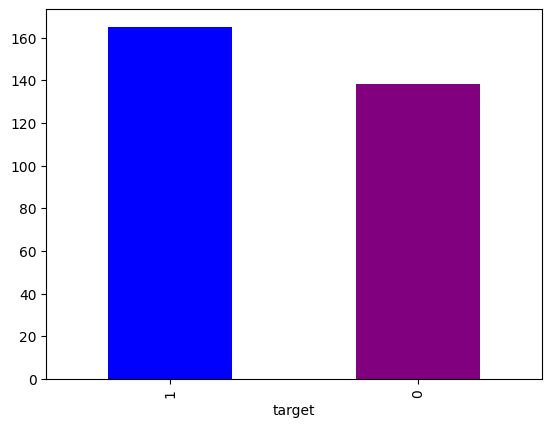

In [ ]:
df["target"].value_counts().plot(kind="bar", color=["blue","purple"])

### **Observation:**
*   **Class 1 (165)** is slightly **higher** than **class 0 (138)**.
*   The **dataset** is **fairly balanced**, with **no extreme class imbalance.**

### **Insight:**
*   The **slight imbalance** may favor **predicting class 1** a bit more often.
*   Since **classes** are **balanced**, **model performance metrics** (**like accuracy/F1**) are **reliable** and **not misleading.**

## **Heart Disease Frequency according to Gender**

In [ ]:
df["sex"].value_counts()

,count
sex,
1,207
0,96


In [ ]:
plot_graph = pd.crosstab(df["target"],df["sex"])
plot_graph

sex,0,1
target,,
0,24,114
1,72,93


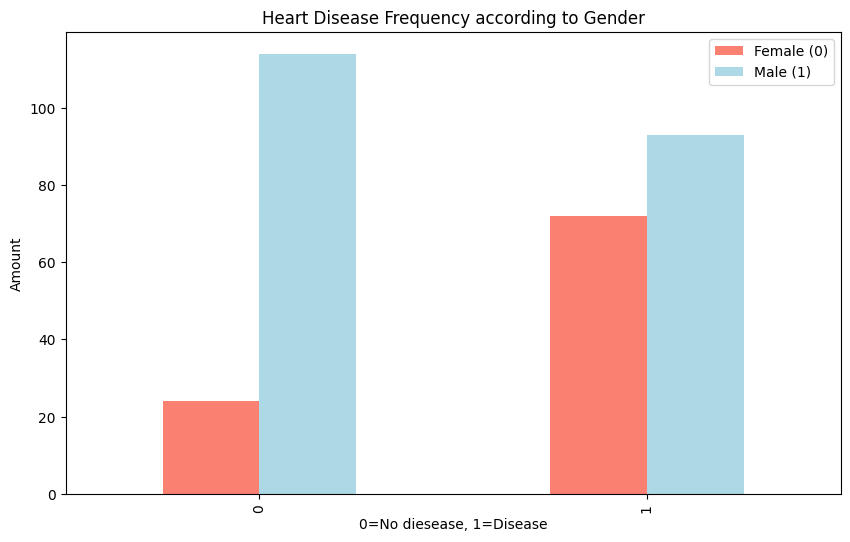

In [ ]:
plot_graph.plot(kind="bar", figsize=(10,6), color=["salmon", "lightblue"])
plt.title("Heart Disease Frequency according to Gender")
plt.xlabel("0=No diesease, 1=Disease")
plt.ylabel("Amount")
plt.legend(["Female (0)", "Male (1)"])
plt.show()

### **Observation:**
**Among individuals without heart disease (target = 0):**
*   114 males
*   24 females

**Among individuals with heart disease (target = 1):**
*   93 males
*   72 females

### **Insight:**

*   A significantly higher number of **males do not have heart disease** compared to females.
*   The number of **males with heart disease is slightly higher than females**, but the gap is much smaller.
*   **Females show a more balanced distribution** between having and not having heart disease.
*   Overall, **heart disease appears more proportionally among females** than males in this dataset.


## **Age vs. Max Heart Rate for Heart Disease**

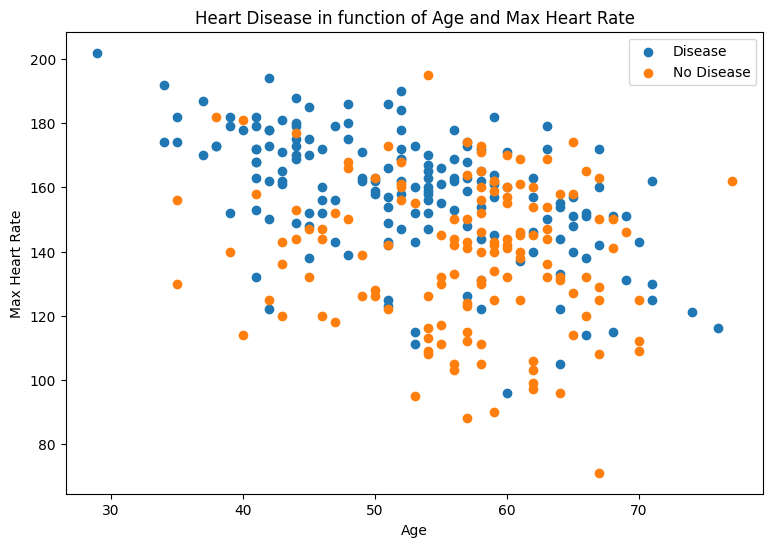

In [ ]:
plt.figure(figsize=(9,6))
# Positive examples
plt.scatter(df.age[df["target"]==1], df.thalach[df["target"]==1])
# Negative examples
plt.scatter(df.age[df["target"]==0], df.thalach[df["target"]==0])

plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease","No Disease"])

### **Observation:**

There is a **negative relationship** between **age** and **max heart rate:**
*   As **age increases**, **maximum heart rate tends to decrease.**

**Individuals with heart disease:**
*  **Cluster more in the middle-to-lower heart rate range**

**Individuals without heart disease:**
*  Show a **wider spread** and **higher heart rates**

### **Insight:**


*   **Maximum heart rate** is **lower on average** for individuals with heart disease, indicating **reduced cardiovascular performance**.
*   **Age and max heart rate** together **show partial separation between groups**, but there is still noticeable overlap.

<Axes: ylabel='Frequency'>

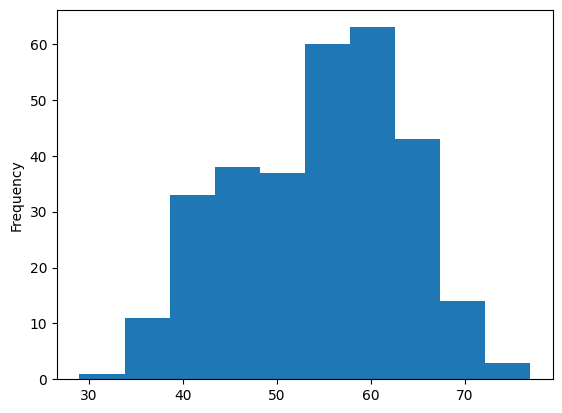

In [ ]:
df["age"].plot(kind="hist")

### **Observation:**
*   Age distribution is **roughly bell-shaped**, centered around **50 to 60 years.**
*   Most individuals **fall between 40 and 65 years**, with fewer at the extremes.

### **Insight:**


*   The dataset is **dominated by middle-aged to older adults**, which may influence model predictions.
*  Results **may not generalize well to younger populations** due to limited representation.

## **Heart Disease Frequency per Chest Pain Type**
### **Chest Pain Type:**

*   **Type 0-Typical angina:** chest pain related decrease blood supply to the heart
*   **Type 1-Atypical angina:** chest pain not related to heart

*   **Type 2-Non-anginal pain:** typically esophageal spasms (non heart related)
*   **Type 3-Asymptomatic:** chest pain not showing signs of disease

In [ ]:
p_graph=pd.crosstab(df["cp"], df["target"])
p_graph

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

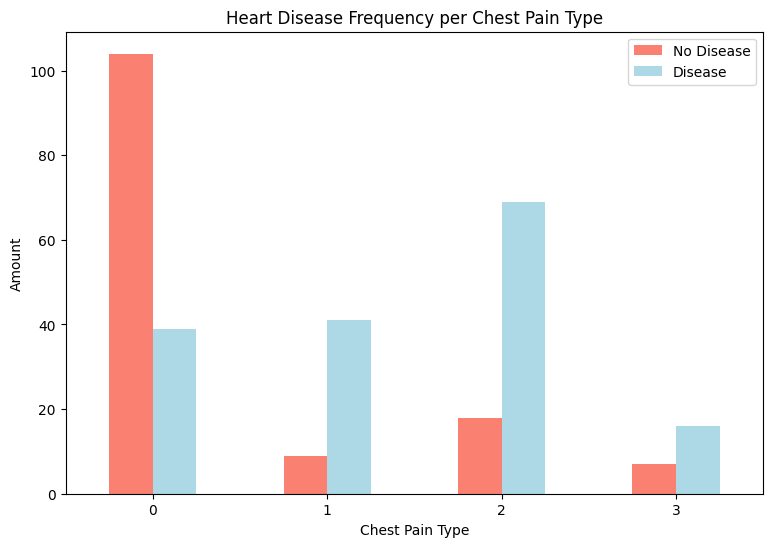

In [ ]:
p_graph.plot(kind="bar", color=["salmon", "lightblue"],figsize=(9,6))
plt.title("Heart Disease Frequency per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0)

### **Observation:**
*   Chest Pain **Type 0** has a much **higher count** of **No Disease** compared to Disease.
*   Chest Pain **Type 2** shows the **highest number of Disease** cases among all types.

### **Insight:**
*   Chest Pain **Type 0** is likely **not a strong indicator of heart disease**
*   Chest Pain **Type 2** appears to be a** high-risk indicator for heart disease.**
*  Chest Pain **Types 1 and 3** may serve as **moderate risk indicators.**

## **Insights:**

<Axes: >

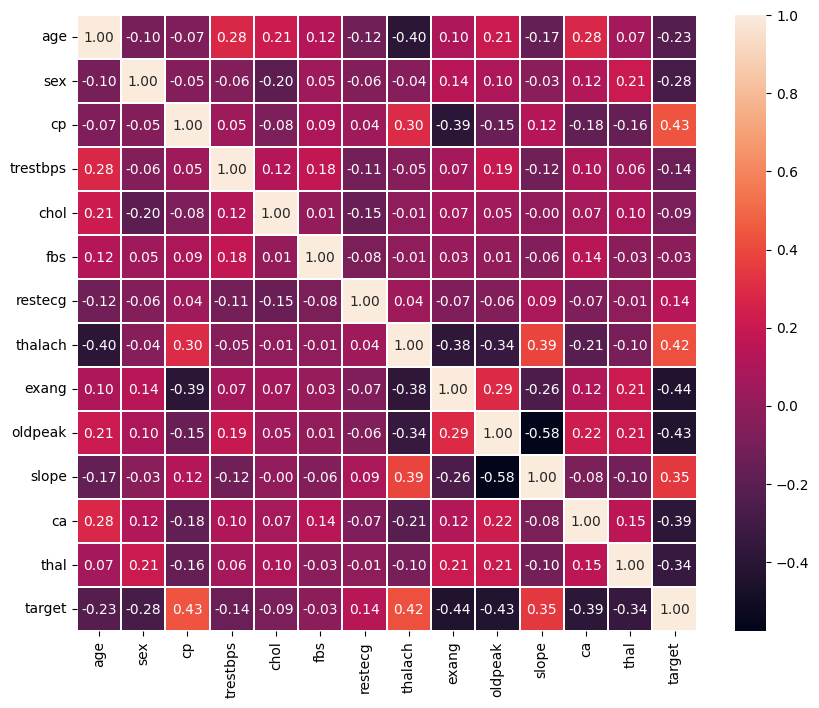

In [ ]:
import seaborn as sns
corr_matrix=df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, linewidth=0.2, fmt=".2f")


*   **Chest pain** and **thalach** show the **strongest positive correlation** with **heart disease**

*    **Exang** and **ST depression (oldpeak**) are **strongly negatively correlated** with the **target**, indicating higher values are associated with lower likelihood of heart disease

## **Modelling**

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
X=df.drop("target", axis=1)
y=df["target"]

In [ ]:
np.random.seed(42)
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2)

## **Choosing a model**

In [ ]:
models={"Logistic Regression":LogisticRegression,
        "Random Forest Classifier": RandomForestClassifier,
}
def fit_and_score(X_train, X_test, y_train, y_test, models):
  np.random.seed(42)
  model_scores={}
  for name, model in models.items():
     model=model()
     model.fit(X_train, y_train)
     model_scores[name]=model.score(X_test, y_test)
  return model_scores

In [ ]:
model_scores=fit_and_score(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test, models=models)
model_scores

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8852459016393442,
 'Random Forest Classifier': 0.8360655737704918}

## **Model Comparison**

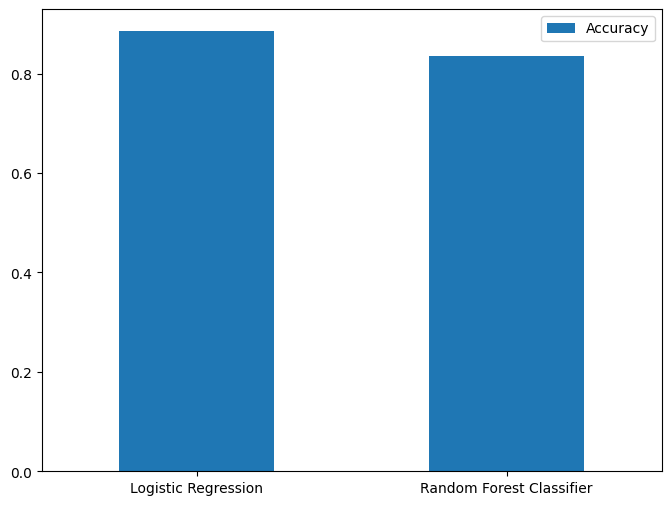

In [ ]:
plot_df=pd.DataFrame(model_scores, index=["Accuracy"])
plot_df.T.plot(kind="bar", figsize=(8,6))
plt.xticks(rotation=0)
plt.show()


### **Observation:**
*   **Logistic Regression** has a **higher accuracy** (around ~0.89) compared to **Random Forest Classifier**
*   Both models perform relatively well, with **accuracy above 80%.**
*   The **difference in accuracy** between the two models is **noticeable** but **not very large**

### **Insight:**

*   **Logistic Regression** is the **better-performing model** for this dataset in terms of accuracy.
*   A simpler model like **Logistic Regression** may be **preferred** due to **efficiency** and **interpretability** while still achieving strong performance.

## **Evaluation**

*   ROC curve and AUC score
*   Confusion matrix
*   Classification report
*   Precision
*   Recall
*   F1-score

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

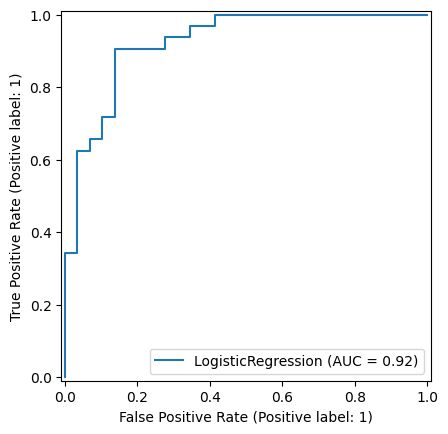

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, X_test, y_test)

### **Observation:**
*   The **ROC curve** is **close to the top-left corner**, indicating strong performance.
*   **AUC ≈ 0.92**, which reflects **excellent classification ability.**

### **Insight:**
*   The model has **high discriminative power**, effectively separating classes.
*   It achieves a **good balance** between **true positives** and **false positives**, making it **reliable** for **prediction tasks.**

In [ ]:
from sklearn.metrics import confusion_matrix
cf=confusion_matrix(y_test, y_preds)
print(cf)

[[25  4]
 [ 3 29]]


Text(50.722222222222214, 0.5, 'Predicted Label')

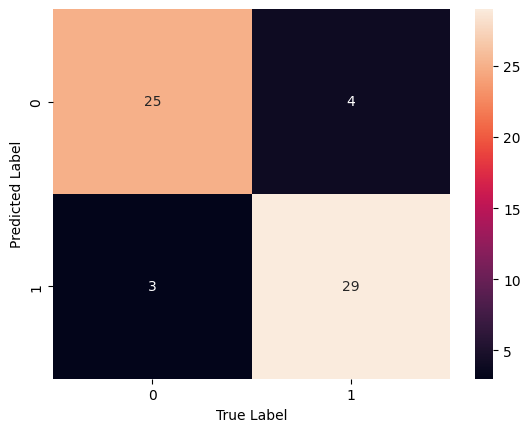

In [ ]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_preds), annot=True)
plt.xlabel("True Label")
plt.ylabel("Predicted Label")


### **Observation:**


*   **True Positives = 29**, **True Negatives = 25** → **Majority of predictions are correct.**
*   **False Positives = 4**, **False Negatives = 3** →** Very few misclassifications.**


### **Insight:**
*   The model shows **strong overall accuracy** with balanced error distribution.
*   Slightly **more false positives** **than false negatives**, meaning it **leans toward predicting the positive class** a bit more.

In [ ]:
class_report=classification_report(y_test, y_preds)
print(class_report)

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



## **Evaluation metrics using cross-validation**

In [ ]:
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [ ]:
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [ ]:
cv_acc=cross_val_score(clf, X,y, cv=5, scoring="accuracy")
cv_acc=np.mean(cv_acc)
cv_acc

np.float64(0.8348633879781422)

In [ ]:
cv_precision=cross_val_score(clf, X,y, cv=5, scoring="precision")
cv_precision=np.mean(cv_precision)
cv_precision

np.float64(0.8251272228245913)

In [ ]:
cv_recall=cross_val_score(clf, X, y, cv=5, scoring="recall")
cv_recall=np.mean(cv_recall)
cv_recall

np.float64(0.8909090909090909)

In [ ]:
cv_f1=cross_val_score(clf, X, y, cv=5, scoring="f1")
cv_f1=np.mean(cv_f1)
cv_f1

np.float64(0.8554265609195187)

Text(0.5, 1.0, 'Cross-validated classification metrics')

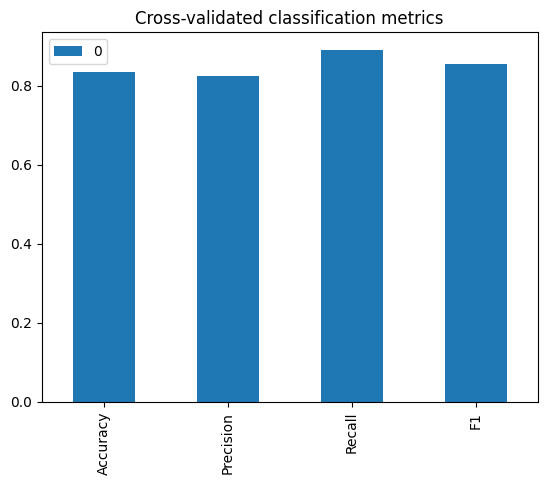

In [ ]:
cv_metrics=pd.DataFrame({
    "Accuracy": cv_acc,
    "Precision": cv_precision,
    "Recall": cv_recall,
    "F1": cv_f1},index=[0])
cv_metrics.T.plot(kind="bar")
plt.title("Cross-validated classification metrics")

### **Observation:**
*   **Recall** has the **highest value** among all metrics
*   **Precision** is **slightly lower** compared to recall
*   **Accuracy** and **F1-score** are **balanced** and fall between precision and recall

### **Insight:**
*   The model is **better** at **identifying positive cases (high recall)**
*   Slightly **lower precision** indicates there are some **false positives**, so not all predicted positives are correct.

# Feature Importance

In [ ]:
clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
coefficients = clf.named_steps["model"].coef_[0]
coefficients

array([-0.08559141, -0.78308552,  0.81790363, -0.27330685, -0.17484121,
        0.09031166,  0.28417893,  0.39513087, -0.51758388, -0.68139635,
        0.43530168, -0.78995525, -0.56565853])

In [ ]:
feature_dict = dict(zip(X.columns, coefficients))
feature_dict

{'age': np.float64(-0.08559140600023729),
 'sex': np.float64(-0.7830855227335495),
 'cp': np.float64(0.8179036309655466),
 'trestbps': np.float64(-0.27330684944434835),
 'chol': np.float64(-0.17484121288174123),
 'fbs': np.float64(0.09031166263166447),
 'restecg': np.float64(0.2841789323126425),
 'thalach': np.float64(0.39513087187613594),
 'exang': np.float64(-0.5175838792013209),
 'oldpeak': np.float64(-0.6813963466155425),
 'slope': np.float64(0.4353016780808153),
 'ca': np.float64(-0.7899552494876225),
 'thal': np.float64(-0.5656585292886971)}

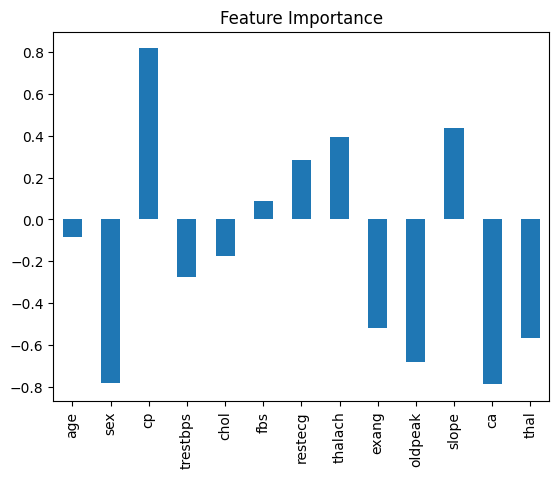

In [ ]:
feature_df = pd.DataFrame(feature_dict, index=[0])
feature_df.T.plot.bar(title="Feature Importance", legend=False);

### **Observation:**

*   **cp (chest pain type)** has the strongest positive influence on prediction.
*   **ca, sex, thal, oldpeak** show **strong negative impact.**
*   Features like **thalach, slope, restecg** have **moderate positive contributions.**

### **Insight:**
*   **Chest pain type** is the **most important predictor** of heart disease in this model.
*   **Negative features** indicate variables that **reduce the likelihood** of the positive class.
*   The model relies on a **mix of clinical and physiological factors**, **not just one variable.**

In [ ]:
pd.crosstab(df["sex"], df["target"])

target,0,1
sex,,
0,24,72
1,114,93


In [ ]:
pd.crosstab(df["slope"], df["target"])

target,0,1
slope,,
0,12,9
1,91,49
2,35,107
